# LED Wall — Static Previews

Icons, elements, and single-frame plugin snapshots.

In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from ledwall_server.plugins.bitcoin import Bitcoin
from ledwall_server.plugins.clock import Clock
from ledwall_server.plugins.effect import ColorCycle, Rainbow, SolidColor
from ledwall_server.plugins.elements import (
    BarElement,
    IconElement,
    RectElement,
    TextElement,
)
from ledwall_server.plugins.icons import ICONS_L, ICONS_S, IconSize
from ledwall_server.plugins.screen import Screen
from ledwall_server.plugins.text import ScrollingText, StaticText
from ledwall_server.plugins.weather import Weather
from picow_ws2812_devtools.visualizer import LedWallVisualizer

In [3]:
W, H = 32, 8
viz = LedWallVisualizer(width=W, height=H, dot_radius=0.3)

## Icon Gallery

All bitmap icons in both sizes: **L** (7×7) and **S** (5×5).

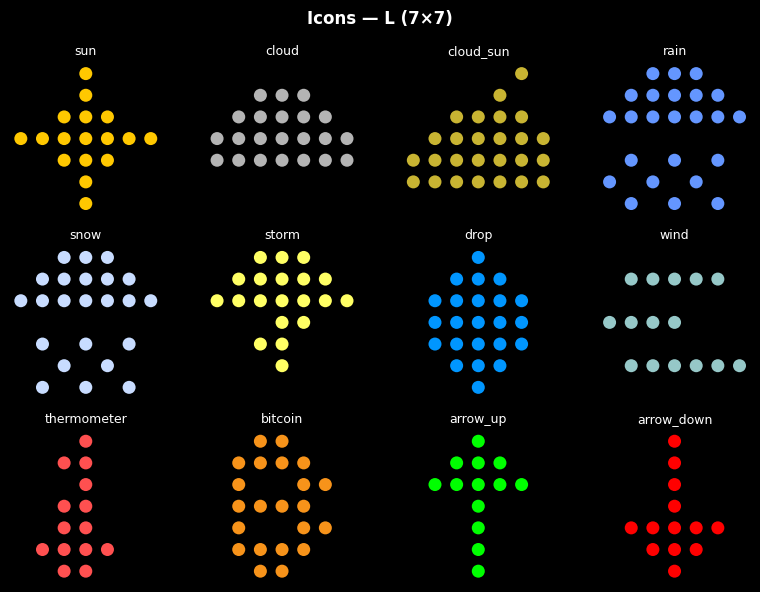

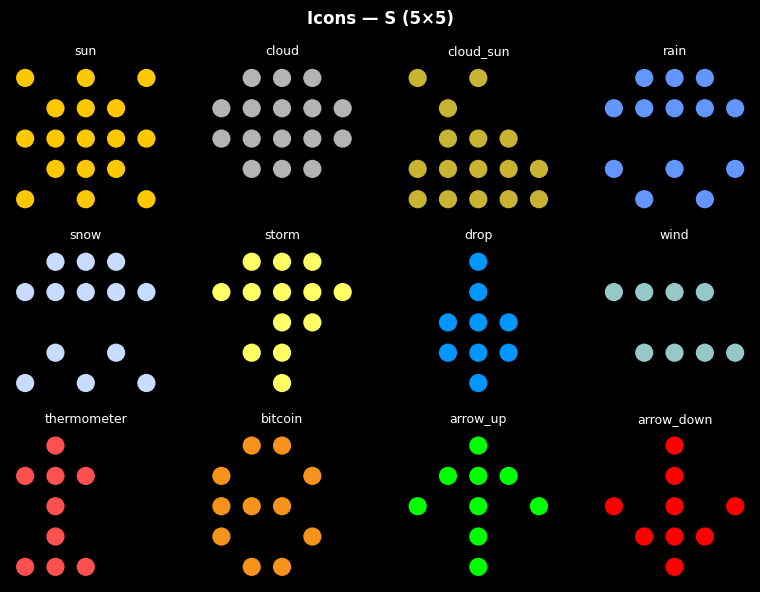

In [4]:
icon_names = list(ICONS_L.keys())
ncols = 4
nrows = (len(icon_names) + ncols - 1) // ncols

colors = {
    "sun": (255, 200, 0),
    "cloud": (180, 180, 180),
    "cloud_sun": (200, 180, 50),
    "rain": (100, 150, 255),
    "snow": (200, 220, 255),
    "storm": (255, 255, 100),
    "drop": (0, 150, 255),
    "wind": (150, 200, 200),
    "thermometer": (255, 80, 80),
    "bitcoin": (247, 147, 26),
    "arrow_up": (0, 255, 0),
    "arrow_down": (255, 0, 0),
}

icon_viz = LedWallVisualizer(dot_radius=0.3)

for label, icons, size in [("Icons — L (7×7)", ICONS_L, 7), ("Icons — S (5×5)", ICONS_S, 5)]:
    fig, axes = plt.subplots(nrows, ncols, figsize=(8, 2 * nrows))
    fig.set_facecolor("black")
    axes = axes.flatten()

    for i, name in enumerate(icon_names):
        canvas = np.zeros((size, size, 3), dtype=np.uint8)
        bitmap = icons[name]
        color = colors.get(name, (255, 255, 255))
        for y, row in enumerate(bitmap):
            for x, ch in enumerate(row):
                if ch == "1":
                    canvas[y, x] = color
        icon_viz.render_frame(axes[i], canvas)
        axes[i].set_title(name, fontsize=9, color="white")

    for i in range(len(icon_names), len(axes)):
        axes[i].set_facecolor("black")
        axes[i].axis("off")

    fig.suptitle(label, fontsize=12, fontweight="bold", color="white")
    fig.tight_layout()

plt.show()

## Elements

Building blocks: `IconElement`, `TextElement`, `BarElement`, `RectElement`.

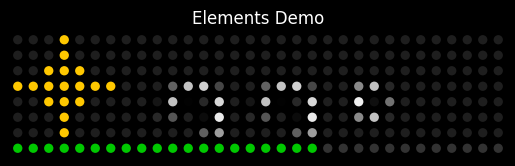

In [5]:
screen = Screen(
    "elements_demo",
    [
        RectElement(0, 0, W, H, color=(30, 30, 30)),
        IconElement(0, 0, 8, 8, icon="sun", color=(255, 200, 0)),
        TextElement(9, 1, 20, 7, text="22°", color=(255, 255, 255)),
        BarElement(0, 7, W, 1, value=0.65, color=(0, 200, 0), bg=(50, 50, 50)),
    ],
)

fig, ax = plt.subplots()
fig.set_facecolor("black")
viz.render_frame(ax, screen.render(W, H))
ax.set_title("Elements Demo", color="white")
plt.show()

## Plugin Snapshots

Single-frame preview of every plugin.

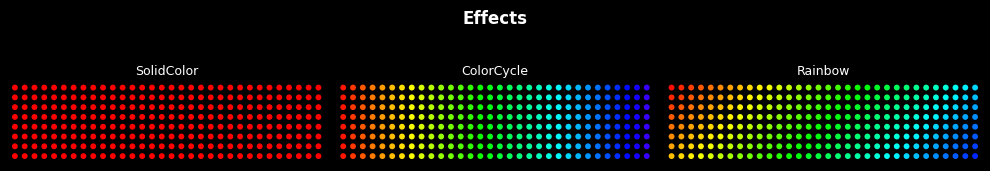

In [6]:
plugins = {
    "SolidColor": SolidColor({"color": [255, 0, 0]}, W, H),
    "ColorCycle": ColorCycle({"speed": 5}, W, H),
    "Rainbow": Rainbow({"speed": 3}, W, H),
}

fig, axes = plt.subplots(1, 3, figsize=(10, 2))
fig.set_facecolor("black")
for ax, (name, plugin) in zip(axes, plugins.items(), strict=True):
    plugin.tick()
    viz.render_frame(ax, plugin.render())
    ax.set_title(name, fontsize=9, color="white")
fig.suptitle("Effects", fontsize=12, fontweight="bold", color="white")
fig.tight_layout()
plt.show()

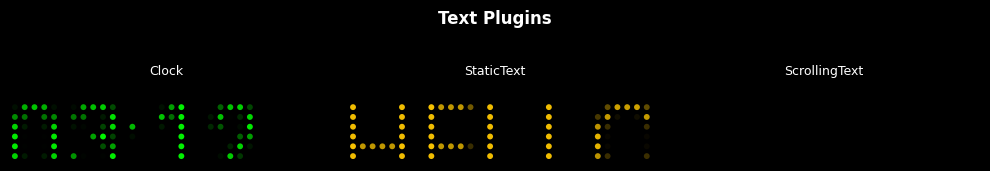

In [7]:
plugins = {
    "Clock": Clock({"color": [0, 255, 0]}, W, H),
    "StaticText": StaticText({"text": "HELLO", "color": [255, 200, 0]}, W, H),
    "ScrollingText": ScrollingText({"text": "LED WALL", "color": [0, 200, 255]}, W, H),
}

fig, axes = plt.subplots(1, 3, figsize=(10, 2))
fig.set_facecolor("black")
for ax, (name, plugin) in zip(axes, plugins.items(), strict=True):
    plugin.tick()
    viz.render_frame(ax, plugin.render())
    ax.set_title(name, fontsize=9, color="white")
fig.suptitle("Text Plugins", fontsize=12, fontweight="bold", color="white")
fig.tight_layout()
plt.show()

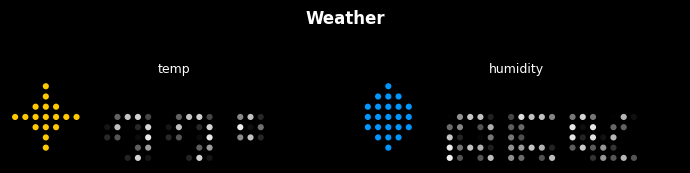

In [8]:
weather = Weather({"screen_mode": "fixed"}, W, H)
weather._temp = "22"
weather._humidity = "65"
weather._weather_code = 0
weather._fetched = True
weather.screen_manager.screens = weather._build_screens()

fig, axes = plt.subplots(1, 2, figsize=(7, 2))
fig.set_facecolor("black")
for i, ax in enumerate(axes):
    viz.render_frame(ax, weather.screen_manager.screens[i].render(W, H))
    ax.set_title(weather.screen_manager.screens[i].name, fontsize=9, color="white")
fig.suptitle("Weather", fontsize=12, fontweight="bold", color="white")
fig.tight_layout()
plt.show()

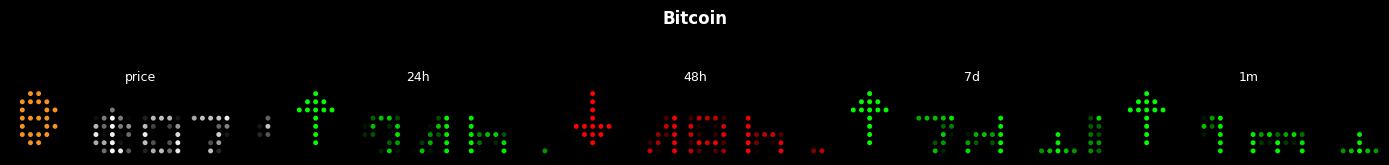

In [9]:
btc = Bitcoin({"screen_mode": "fixed"}, W, H)
btc._price = 97200.0
btc._trends = {"24h": 2.3, "48h": -1.5, "7d": 5.2, "1m": 12.1}
btc._fetched = True
btc.screen_manager.screens = btc._build_screens()

screens = btc.screen_manager.screens
fig, axes = plt.subplots(1, len(screens), figsize=(14, 2))
fig.set_facecolor("black")
for ax, screen in zip(axes, screens, strict=True):
    viz.render_frame(ax, screen.render(W, H))
    ax.set_title(screen.name, fontsize=9, color="white")
fig.suptitle("Bitcoin", fontsize=12, fontweight="bold", color="white")
fig.tight_layout()
plt.show()